<a href="https://colab.research.google.com/github/PaNjodv/CNN_FINALProject/blob/main/Final_Project_Option1_CNN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

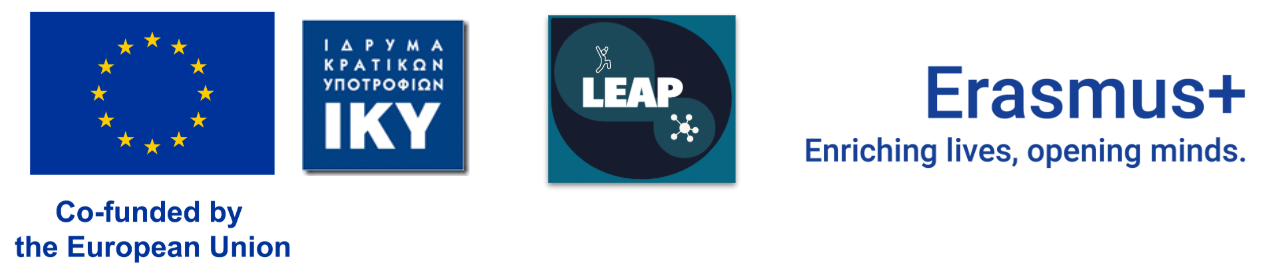

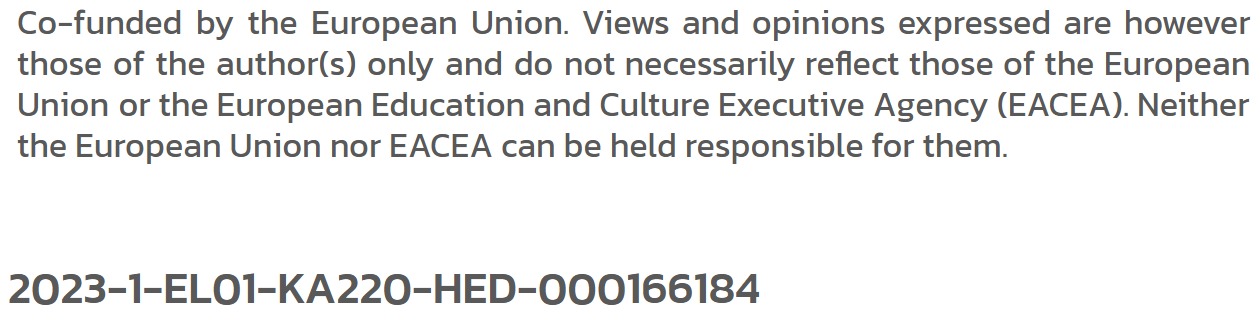

# Final Project, Option 1: Where does your CNN make its mistakes?

Software that reads handwritten numbers, such as postcodes on envelopes or account numbers on paper forms, must be judged not only on how often it is right but on where it goes wrong, because a confident misreading carries a real cost. In this project you build such a model and study the mistakes it makes.

In this project you build a convolutional neural network that recognises handwritten digits, then you study the mistakes it makes.

**Central question:** where does your CNN make its mistakes, and does one change to the model move them?

The data set is MNIST: 70,000 images of handwritten digits, each 28 by 28 pixels in greyscale, labelled 0 to 9. You download it yourself in the next cell.

This project draws on two earlier modules. In Module 5, we built and trained dense neural networks in Keras. In Module 6, we added convolutional layers, used Dropout and EarlyStopping to control overfitting, and read a confusion matrix to see which classes a model mixes up. Here you bring those skills together on a larger, more varied data set.

**How this notebook is organised.** The cells in Part A are already written for you. They handle the import, the download, and the reshaping that turns each flat row of 784 numbers back into a 28 by 28 image. From Part B onward, the cells are yours to complete. Each one carries comments describing what to do, along with a few hints, but not the finished code. Work through them in order.

Training on the full data set may take a few minutes per epoch on a laptop without a graphics card. This is expected.

## Part A. Setup and data

We start with the imports. This cell loads everything the notebook needs, so we run it once at the top.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import keras
from keras import layers

### Loading the data

We download MNIST from OpenML. The call returns the images in `X` as 70,000 rows of 784 numbers, and the labels in `y` as text. We convert the labels to integers so the model can work with them. The download runs once and may take a moment.

In [ ]:
X, y = fetch_openml("mnist_784", version=1, as_frame=False, return_X_y=True)
y = y.astype(int)

print("Images:", X.shape)
print("Labels:", y.shape, "| classes:", np.unique(y))

Images: (70000, 784)
Labels: (70000,) | classes: [0 1 2 3 4 5 6 7 8 9]


### Preparing the images

Each row of `X` is one image flattened into a line of 784 numbers. We reshape every row back into a 28 by 28 image with a single greyscale channel, and we scale the pixel values from the range 0 to 255 down to the range 0 to 1, which helps the network train. We then split the data into a training set and a test set, keeping the class balance with `stratify`, as we did in Module 3.

In [ ]:
X = X.reshape(-1, 28, 28, 1).astype("float32") / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training images:", X_train.shape)
print("Test images:    ", X_test.shape)

# If training is slow on your machine, you may work with a smaller sample
# while you get everything running, for example:
#   X_train, y_train = X_train[:10000], y_train[:10000]

Training images: (56000, 28, 28, 1)
Test images:     (14000, 28, 28, 1)


### A first look at the images

Before modelling, we look at a few training images with their labels, to confirm the data loaded correctly.

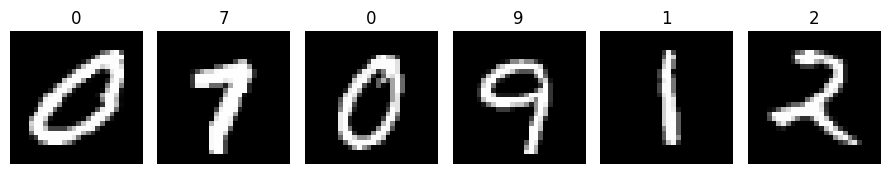

In [ ]:
fig, axes = plt.subplots(1, 6, figsize=(9, 2))
for ax, image, label in zip(axes, X_train, y_train):
    ax.imshow(image.reshape(28, 28), cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")
plt.tight_layout()
plt.show()

## Part B. Build and train your network

From here on, the cells are yours to complete.

First, build a convolutional neural network with the Keras Sequential API, the same style you used in Module 6. Recall the shape of one image: 28 by 28, with one channel.

In [ ]:
keras.utils.set_random_seed(42)

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,442 (1.54 MB)

 Trainable params: 402,442 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

### Compile the model

Compiling sets the optimiser, the loss function, and the metric to watch during training.

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


### Train the model

Train the network, watching how it performs on data it has not learnt from. `EarlyStopping` halts training once the validation loss stops improving, so you do not waste time or overfit.

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 32s 78ms/step - accuracy: 0.9160 - loss: 0.3008 - val_accuracy: 0.9646 - val_loss: 0.1190
Epoch 2/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.9703 - loss: 0.1010 - val_accuracy: 0.9762 - val_loss: 0.0807
Epoch 3/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.9772 - loss: 0.0750 - val_accuracy: 0.9807 - val_loss: 0.0641
Epoch 4/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9815 - loss: 0.0608 - val_accuracy: 0.9816 - val_loss: 0.0572
Epoch 5/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9841 - loss: 0.0514 - val_accuracy: 0.9839 - val_loss: 0.0517
Epoch 6/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.9862 - loss: 0.0448 - val_accuracy: 0.9845 - val_loss: 0.0495
Epoch 7/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.9871 - loss: 0.0393 - val_accuracy: 0.9861 - val_loss: 0.0469
Epoch 8/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 39s 74ms/step - accuracy: 0.9893 - loss: 0.0332 - 

### Learning curves

Plot the training and validation loss across the epochs. A validation curve that flattens or turns upward while the training curve keeps falling is a sign of overfitting.

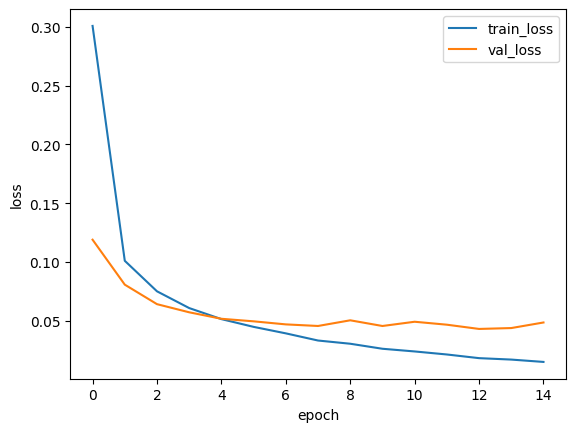

In [ ]:
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.legend()
plt.show()


## Part C. Read the mistakes

Now measure how well the model does on the test set, the images it has never seen. This gives a reliable estimate of how it will perform on new images.

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

print(f"Test accuracy: {test_accuracy:.3f}")
print(f"Test loss: {test_loss:.3f}")


Test accuracy: 0.987
Test loss: 0.046


### The confusion matrix

The confusion matrix is where you answer the first half of the central question: where the mistakes are. Read it by rows. Each row is a true digit, each column is the digit the model predicted. The diagonal holds the correct predictions; every off-diagonal cell is a mistake, and its position tells you which digit was mistaken for which.

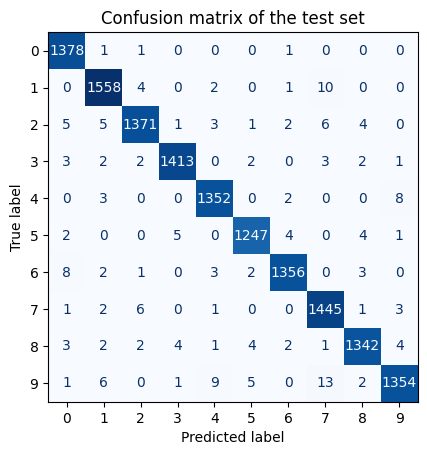

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred), display_labels=range(10))
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion matrix of the test set")
plt.show()


### What did you find?

The main mix-ups are true 9s being misclassified as 7s (13 times) and true 1s as 7s (10 times). A 9 looks like a 7 if the top loop isn't fully closed, while a 1 easily gets mistaken for a 7 if it has a noticeable top stroke. Since both 9 and 1 share that sharp vertical line with a 7, messy handwriting confuses the model.

## Part D. One change

Now answer the second half of the central question: does one change to the model move the mistakes?

Choose **one** change from the two below. Do not make both at once, or you will not know which one caused any difference you see.

- **Option B: stronger regularisation.** Raise the Dropout rate from 0.3 to 0.5. This makes the network rely less on any single feature.

**Before you run anything, write down your prediction:** will your chosen change raise the test accuracy, and will it reduce the confusion between the pairs you found in Part C? Note it here.

I expect val_loss to flatten similarly but more smoothly, train_loss to plateau higher and slower, and the train/val gap to shrink ,but I don't expect a large change in final test accuracy, since the original model wasn't overfitting severely.

In [ ]:

keras.utils.set_random_seed(42)

model2 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,442 (1.54 MB)

 Trainable params: 402,442 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
history2 = model2.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.9082 - loss: 0.3232 - val_accuracy: 0.9661 - val_loss: 0.1203
Epoch 2/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 31s 76ms/step - accuracy: 0.9651 - loss: 0.1179 - val_accuracy: 0.9757 - val_loss: 0.0817
Epoch 3/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.9721 - loss: 0.0888 - val_accuracy: 0.9811 - val_loss: 0.0667
Epoch 4/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.9766 - loss: 0.0751 - val_accuracy: 0.9832 - val_loss: 0.0595
Epoch 5/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.9789 - loss: 0.0652 - val_accuracy: 0.9836 - val_loss: 0.0521
Epoch 6/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.9820 - loss: 0.0568 - val_accuracy: 0.9855 - val_loss: 0.0495
Epoch 7/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 42s 74ms/step - accuracy: 0.9839 - loss: 0.0505 - val_accuracy: 0.9857 - val_loss: 0.0461
Epoch 8/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.9849 - loss: 0.0444 -

Test accuracy (model1): 0.987   Test accuracy (model2): 0.988


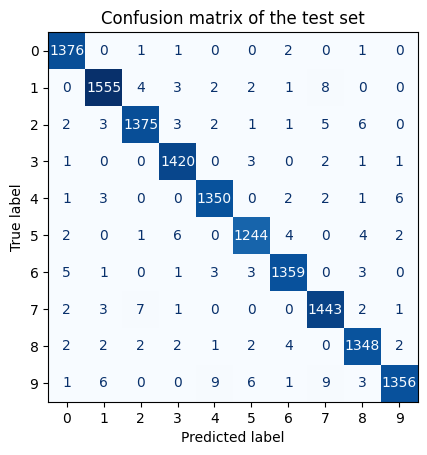

In [ ]:
test_loss2 , test_accuracy2 = model2.evaluate(X_test, y_test, verbose=0)
y_pred2 = np.argmax(model2.predict(X_test, verbose=0), axis=1)

print(f"Test accuracy (model1): {test_accuracy:.3f}   Test accuracy (model2): {test_accuracy2:.3f}")

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred2), display_labels=range(10))
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion matrix of the test set")
plt.show()


### Ethical considerations

If deployed in a real system, the model could fail more often for elderly people, children, or international writers whose digit styles differ from the training data. A confident but incorrect prediction could lead to automated errors,such as wrong bank transfers or misfiled records, without flagging a human to doublecheck.


## Wrapping up

Bring your findings together. **Write a short paragraph** that answers the central question directly:

- Where did your first model make most of its mistakes?
- Did your prediction in Part D turn out to be correct?
- For each of the two confusion pairs you identified, what was the count before and after the change?
- Did your one change move the mistakes, and is the difference large enough to be meaningful?

Model 1 mostly confused 9s with 7s (13 times) and 1s with 7s (10 times). I predicted that raising dropout from 0.3 to 0.5 would reduce these mix-ups, and it did: the 9 to 7 errors dropped from 13 to 9, and the 1 to 7 errors dropped from 10 to 8. So my prediction was right, but the change was small, accuracy only went up from 0.987 to 0.988.